# Counting objects with LLMs

---
*Introduction to Image Analysis Workshop*

*Stefania Marcotti (stefania.marcotti@crick.ac.uk) and Dave Barry (david.barry@crick.ac.uk)*

*Intro to using LLMs for image analysis*

*CC-BY-SA-4.0 license: creativecommons.org/licenses/by-sa/4.0/*

---

In this notebook, we build on earlier work to show how LLMs can be used to count objects in microscopy images.

Below you will see the code provided by a number of different LLMs when given the following prompt and the idridr0028_003003-10_C1.tif image:

"_Can you write me some concise python code, suitable to put in a single cell in a Jupyter notebook, to count the objects in this image, using libraries such as scikit-image and numpy?_"

## Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
from skimage import color
from skimage import filters, morphology, segmentation, measure, feature
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
from skimage.morphology import opening, disk, remove_small_objects
from skimage.segmentation import watershed

## Open images

To get started with our "counting objects" task, the first thing we need to do is to open an image.

In [2]:
# read .tif file
img = io.imread('../../Data/data_for_ilastik/idr0028_003003-10_C1.tif')

In [3]:
# print image type
print('Image type:', type(img))

Image type: <class 'numpy.ndarray'>


In [4]:
# print image dimensions
print('Image dimensions:', img.shape)

Image dimensions: (501, 667)


## Count Objects

### GPT-5.5 Instant

In [5]:
# Smooth + background subtraction
img_smooth = filters.gaussian(img, sigma=2)
bg = filters.gaussian(img, sigma=20)
img_corr = img_smooth - bg

# Threshold
th = filters.threshold_otsu(img_corr)
mask = img_corr > th

# Clean up
mask = morphology.remove_small_objects(mask, min_size=50)
mask = morphology.remove_small_holes(mask, area_threshold=50)

# Separate touching objects (watershed)
dist = morphology.distance_transform_edt(mask)
peaks = feature.peak_local_max(dist, labels=mask, min_distance=8)
markers = np.zeros_like(img, dtype=int)
markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)
labels = segmentation.watershed(-dist, markers, mask=mask)

# Count objects
props = measure.regionprops(labels)
print("Object count:", len(props))

AttributeError: module 'skimage.morphology' has no attribute 'distance_transform_edt'

### Claude Opus 4.7

Number of objects: 23


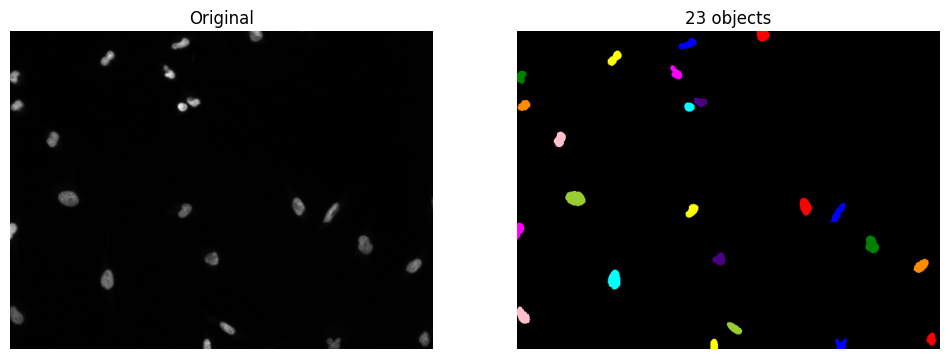

In [6]:
# Threshold + clean up
binary = img > filters.threshold_otsu(img)
binary = morphology.remove_small_objects(binary, min_size=50)
binary = ndi.binary_fill_holes(binary)

# Label and count
labels = measure.label(binary)
print(f"Number of objects: {labels.max()}")

# Quick visual check
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img, cmap='gray');
ax[0].set_title('Original')
ax[1].imshow(color.label2rgb(labels, bg_label=0));
ax[1].set_title(f'{labels.max()} objects')
for a in ax: a.axis('off')
plt.show()

### CoPilot Chat (GPT-5)

Object count: 23


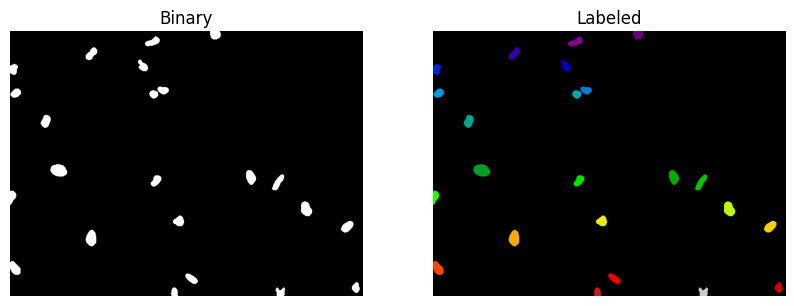

In [7]:
# If RGB, convert to grayscale
if img.ndim == 3:
    img = img.mean(axis=2)

# Smooth to reduce noise
img_blur = filters.gaussian(img, sigma=1)

# Threshold (Otsu)
thresh = filters.threshold_otsu(img_blur)
binary = img_blur > thresh

# Remove small objects (noise)
binary = morphology.remove_small_objects(binary, min_size=50)

# Optional: separate touching objects slightly
binary = morphology.opening(binary, morphology.disk(2))

# Label connected regions
labels = measure.label(binary)
count = labels.max()

print("Object count:", count)

# Visualise
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Binary")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Labeled")
plt.imshow(labels, cmap='nipy_spectral')
plt.axis('off')

plt.show()

### Mistral Medium 3.5

In [8]:
# Convert to grayscale if necessary (though the image seems already binary)
gray_image = rgb2gray(img) if img.ndim == 3 else img

# Apply Otsu's thresholding to ensure binary image
thresh = threshold_otsu(gray_image)
binary_image = gray_image > thresh

# Label connected regions
labeled_image = measure.label(binary_image, connectivity=2)

# Count the number of objects
num_objects = np.max(labeled_image)

print(f"Number of objects: {num_objects}")

Number of objects: 24


### Gemini 3

Detected 24 objects in the image.


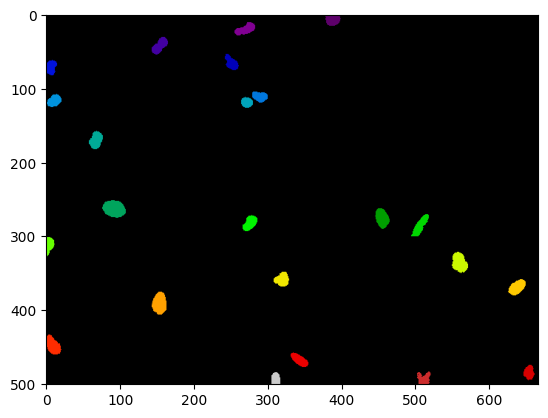

In [9]:
# 2. Thresholding: Automatically find the cutoff between background and objects
# Using Otsu's method, which handles dark backgrounds well
thresh = filters.threshold_otsu(img)
binary = img > thresh

# 3. Cleanup: Remove tiny noise pixels (artifacts) that aren't real objects
# Adjust 'min_size' if your objects are very small or very large
clean_mask = morphology.remove_small_objects(binary, min_size=5)

# 4. Labeling: Identify distinct clusters of pixels
labels = measure.label(clean_mask)

print(f"Detected {labels.max()} objects in the image.")

# Optional: Visualize the result to verify accuracy

plt.imshow(labels, cmap='nipy_spectral')
plt.show()

## Overall, they do pretty well

But the image they were given is a pretty straightforward one to analyse. What if they were given something more sub-optimal?

In [10]:
# read .tif file
img = io.imread('../../Data/data_for_ilastik/idr0028_003003-10_C3.tif')

### GPT-5.5 Instant

In [11]:
# Smooth + threshold
img_smooth = gaussian(img, sigma=1)
mask = img_smooth > threshold_otsu(img_smooth)

# Clean up mask
mask = opening(mask, disk(2))
mask = remove_small_objects(mask, min_size=50)

# Separate touching objects using watershed
dist = ndi.distance_transform_edt(mask)
local_max = (ndi.maximum_filter(dist, size=15) == dist) & mask
markers = label(local_max)
labels = watershed(-dist, markers, mask=mask)

print("Object count:", labels.max())

Object count: 30


### Claude Opus 4.7

Number of objects: 23


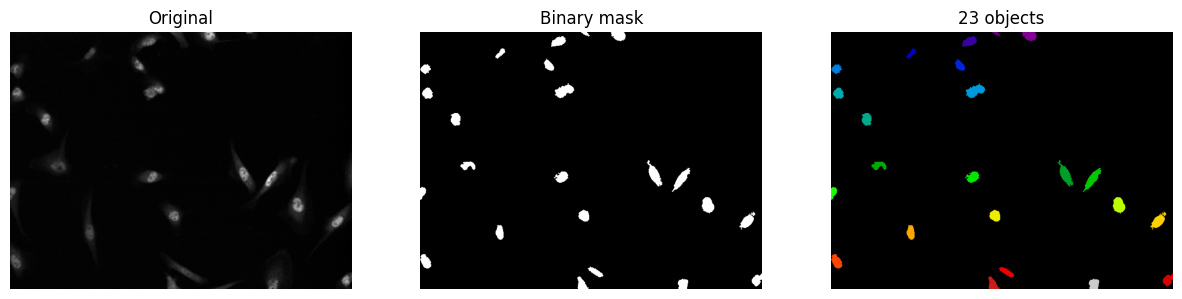

In [12]:
# Threshold (Otsu picks a sensible cutoff between background and nuclei)
binary = img > filters.threshold_otsu(img)

# Clean up: drop specks and fill small holes inside nuclei
binary = morphology.remove_small_objects(binary, min_size=50)
binary = morphology.remove_small_holes(binary, area_threshold=50)

# Label connected components and count
labels = measure.label(binary)
n_objects = labels.max()
print(f"Number of objects: {n_objects}")

# Visualize
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img, cmap='gray');
ax[0].set_title('Original')
ax[1].imshow(binary, cmap='gray');
ax[1].set_title('Binary mask')
ax[2].imshow(labels, cmap='nipy_spectral');
ax[2].set_title(f'{n_objects} objects')
for a in ax: a.axis('off')
plt.show()

### CoPilot Chat (GPT-5)

Object count: 23


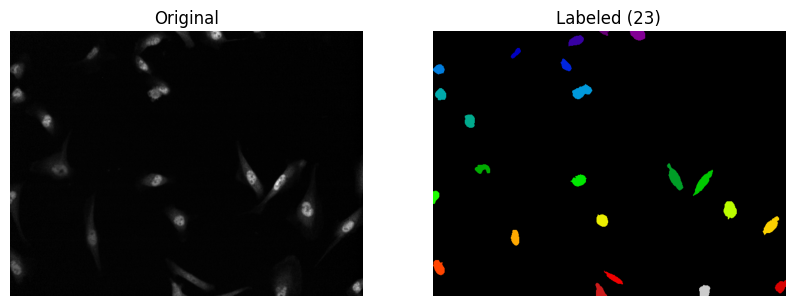

In [13]:
# Smooth + threshold
blur = filters.gaussian(img, sigma=1)
th = filters.threshold_otsu(blur)
bw = blur > th

# Clean up (remove small noise)
bw = morphology.remove_small_objects(bw, min_size=50)
bw = morphology.remove_small_holes(bw, area_threshold=50)

# Label and count objects
labels = measure.label(bw)
count = labels.max()

print(f"Object count: {count}")

# Optional: visualize
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1);
plt.imshow(img, cmap='gray');
plt.axis('off');
plt.title('Original')
plt.subplot(1, 2, 2);
plt.imshow(labels, cmap='nipy_spectral');
plt.axis('off');
plt.title(f'Labeled ({count})')
plt.show()

### Mistral Medium 3.5

In [14]:
# Convert to grayscale if necessary
gray_image = rgb2gray(img) if img.ndim == 3 else img

# Apply thresholding to create a binary image
threshold_value = filters.threshold_otsu(gray_image)
binary_image = gray_image > threshold_value

# Label connected components
labeled_image = measure.label(binary_image)

# Count the number of objects
num_objects = np.max(labeled_image)

print(f"Number of objects: {num_objects}")

Number of objects: 48


### Gemini 3

In [15]:
# 2. Thresholding to create a binary mask
# Using Otsu's method to separate objects from the background
thresh = filters.threshold_otsu(img)
binary = img > thresh

# 3. Optional: Remove tiny noise/artifacts (min_size is in pixels)
cleaned = morphology.remove_small_objects(binary, min_size=5)

# 4. Label connected components and count
labels, count = measure.label(cleaned, return_num=True)

print(f"Detected {count} objects in the image.")

Detected 31 objects in the image.
